In [45]:
import gymnasium as gym
from stable_baselines3 import PPO
import numpy as np
import plotly.graph_objects as go

import matplotlib.pyplot as plt

from ctrlab.envs.hoversb import Hover
from ctrlab.utils.quaternion import euler_to_quat
from ctrlab import crazyflie

# Load drone parameters
mass = crazyflie['mass']
inertia = crazyflie['inertia']
G1 = crazyflie['G1']
tau = crazyflie['tau']

# Create environment instance
env = Hover(mass=mass, 
            inertia=inertia, 
            G1=G1,
            tau=tau,
            dt=np.float32(0.01)
            )

# Load trained model
model = PPO.load("checkpoints/ppo_hover_2000000_steps", env=env)



Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [46]:
# Run a single test episode
obs, _ = env.reset()
done = False
total_reward = 0
step = 0

states = []
actions = []

states.append(obs.copy())

print("\n--- Starting Test Episode ---")

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    states.append(obs.copy())
    actions.append(action.copy())
    total_reward += reward
    step += 1
    print(f"Step: {step}, Reward: {reward:.2f}, Done: {done}")


print(f"--- Episode finished in {step} steps, Total Reward: {total_reward:.2f} ---")

states = np.array(states)
actions = np.array(actions)


--- Starting Test Episode ---
Step: 1, Reward: -0.44, Done: False
Step: 2, Reward: -0.44, Done: False
Step: 3, Reward: -0.46, Done: False
Step: 4, Reward: -0.50, Done: False
Step: 5, Reward: -0.52, Done: False
Step: 6, Reward: -0.52, Done: False
Step: 7, Reward: -0.50, Done: False
Step: 8, Reward: -0.48, Done: False
Step: 9, Reward: -0.47, Done: False
Step: 10, Reward: -0.49, Done: False
Step: 11, Reward: -0.50, Done: False
Step: 12, Reward: -0.50, Done: False
Step: 13, Reward: -0.48, Done: False
Step: 14, Reward: -0.44, Done: False
Step: 15, Reward: -0.42, Done: False
Step: 16, Reward: -0.41, Done: False
Step: 17, Reward: -0.40, Done: False
Step: 18, Reward: -0.37, Done: False
Step: 19, Reward: -0.34, Done: False
Step: 20, Reward: -0.34, Done: False
Step: 21, Reward: -0.36, Done: False
Step: 22, Reward: -0.40, Done: False
Step: 23, Reward: -0.41, Done: False
Step: 24, Reward: -0.38, Done: False
Step: 25, Reward: -0.32, Done: False
Step: 26, Reward: -0.29, Done: False
Step: 27, Reward

In [47]:
# Create figure
fig = go.Figure()

# Trajectory line
fig.add_trace(go.Scatter3d(
    x=states[:, 0],
    y=states[:, 1],
    z=states[:, 2],
    mode='lines',
    line=dict(color='black'),
    name='Trajectory'
))

# Start point
fig.add_trace(go.Scatter3d(
    x=[states[0, 0]],
    y=[states[0, 1]],
    z=[states[0, 2]],
    mode='markers',
    marker=dict(color='red', size=6),
    name='Start'
))

# End point
fig.add_trace(go.Scatter3d(
    x=[states[-1, 0]],
    y=[states[-1, 1]],
    z=[states[-1, 2]],
    mode='markers',
    marker=dict(color='green', size=6),
    name='End'
))

# Goal at origin
fig.add_trace(go.Scatter3d(
    x=[0],
    y=[0],
    z=[0],
    mode='markers',
    marker=dict(color='blue', size=6),
    name='Goal'
))

# Layout
fig.update_layout(
    scene=dict(
        xaxis=dict(title='x', range=[-1.2, 1.2]),
        yaxis=dict(title='y', range=[-1.2, 1.2]),
        zaxis=dict(title='z', range=[1.2, -1.2])  # Inverted Z-axis
    ),
    width=800,
    height=800,
    showlegend=True
)

fig.show()

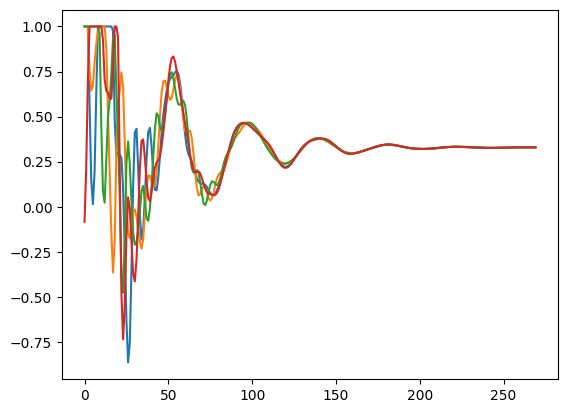

In [48]:
plt.plot(actions[:,0])
plt.plot(actions[:,1])
plt.plot(actions[:,2])
plt.plot(actions[:,3])

Text(0.5, 1.0, 'Motor RPM')

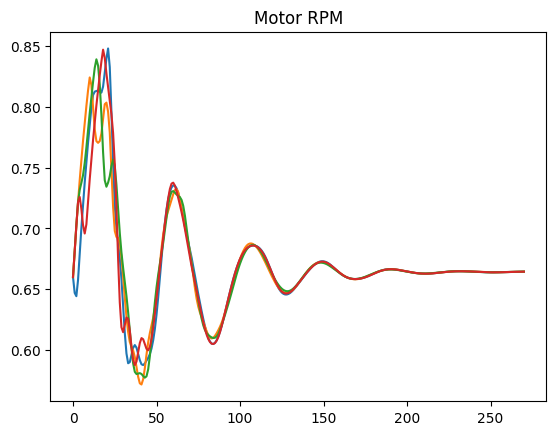

In [49]:
plt.plot(states[:,-1])
plt.plot(states[:,-2])
plt.plot(states[:,-3])
plt.plot(states[:,-4])

plt.title("Motor RPM")

Text(0.5, 1.0, 'Body rates')

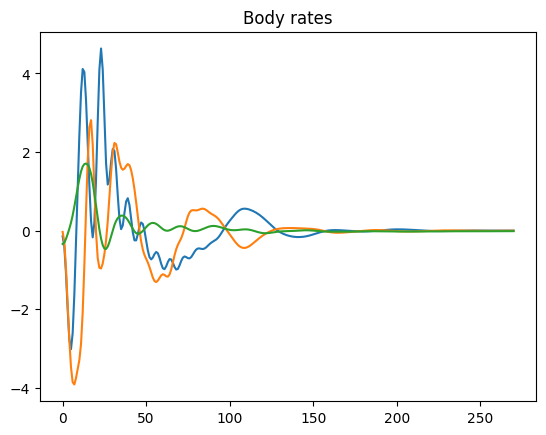

In [50]:
plt.plot(states[:,10])
plt.plot(states[:,11])
plt.plot(states[:,12])
plt.title("Body rates")